In [37]:


import os
import glob
import pandas as pd

script_dir =os.getcwd()
# Build the absolute path to the file in the 'out' folder (located in the parent directory)
folder_path = os.path.join(script_dir, 'Asymptoticity_IC_0301','out')

# Find all CSV files in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Create a dictionary to store the DataFrames with keys as file names
dataframes = {}

for csv_file in csv_files:
    # Extract the file name without extension
    file_name = os.path.splitext(os.path.basename(csv_file))[0]
    # Read the CSV file into a DataFrame
    dataframes[file_name] = pd.read_csv(csv_file)

In [38]:
csv_files

['/Users/liyi/Documents/GitHub/EM_HAL_1D/Asymptoticity_IC_0301/out/hal_n1600_smooth1_ridge1e-06_final_survival.csv',
 '/Users/liyi/Documents/GitHub/EM_HAL_1D/Asymptoticity_IC_0301/out/hal_n200_smooth0_ridge1e-06_final_survival_se.csv',
 '/Users/liyi/Documents/GitHub/EM_HAL_1D/Asymptoticity_IC_0301/out/hal_n3200_smooth1_ridge1e-06_final_survival_se.csv',
 '/Users/liyi/Documents/GitHub/EM_HAL_1D/Asymptoticity_IC_0301/out/hal_n200_smooth1_ridge1e-06_final_density.csv',
 '/Users/liyi/Documents/GitHub/EM_HAL_1D/Asymptoticity_IC_0301/out/hal_n1600_smooth1_ridge1e-06_final_survival_se.csv',
 '/Users/liyi/Documents/GitHub/EM_HAL_1D/Asymptoticity_IC_0301/out/hal_n3200_smooth1_ridge1e-06_initial_survival.csv',
 '/Users/liyi/Documents/GitHub/EM_HAL_1D/Asymptoticity_IC_0301/out/hal_n3200_smooth0_ridge1e-06_initial_survival_se.csv',
 '/Users/liyi/Documents/GitHub/EM_HAL_1D/Asymptoticity_IC_0301/out/hal_n1600_smooth0_ridge1e-06_initial_density_se.csv',
 '/Users/liyi/Documents/GitHub/EM_HAL_1D/Asympt


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Oracle_1 Coverage results for hal_n200_smooth1_ridge1e-06_final_density:
    Evaluation Point  True Density  Oracle Coverage (%)
0           0.000000      0.000015                 98.4
1           0.010101      0.000025                 98.0
2           0.020202      0.000040                 97.6
3           0.030303      0.000065                 97.2
4           0.040404      0.000103                 97.0
..               ...           ...                  ...
95          0.959596      0.000103                 98.2
96          0.969697      0.000065                 98.4
97          0.979798      0.000040                 98.6
98          0.989899      0.000025                 98.8
99          1.000000      0.000015                 98.8

[100 rows x 3 columns] 

Oracle_1 Coverage results for hal_n3200_smooth

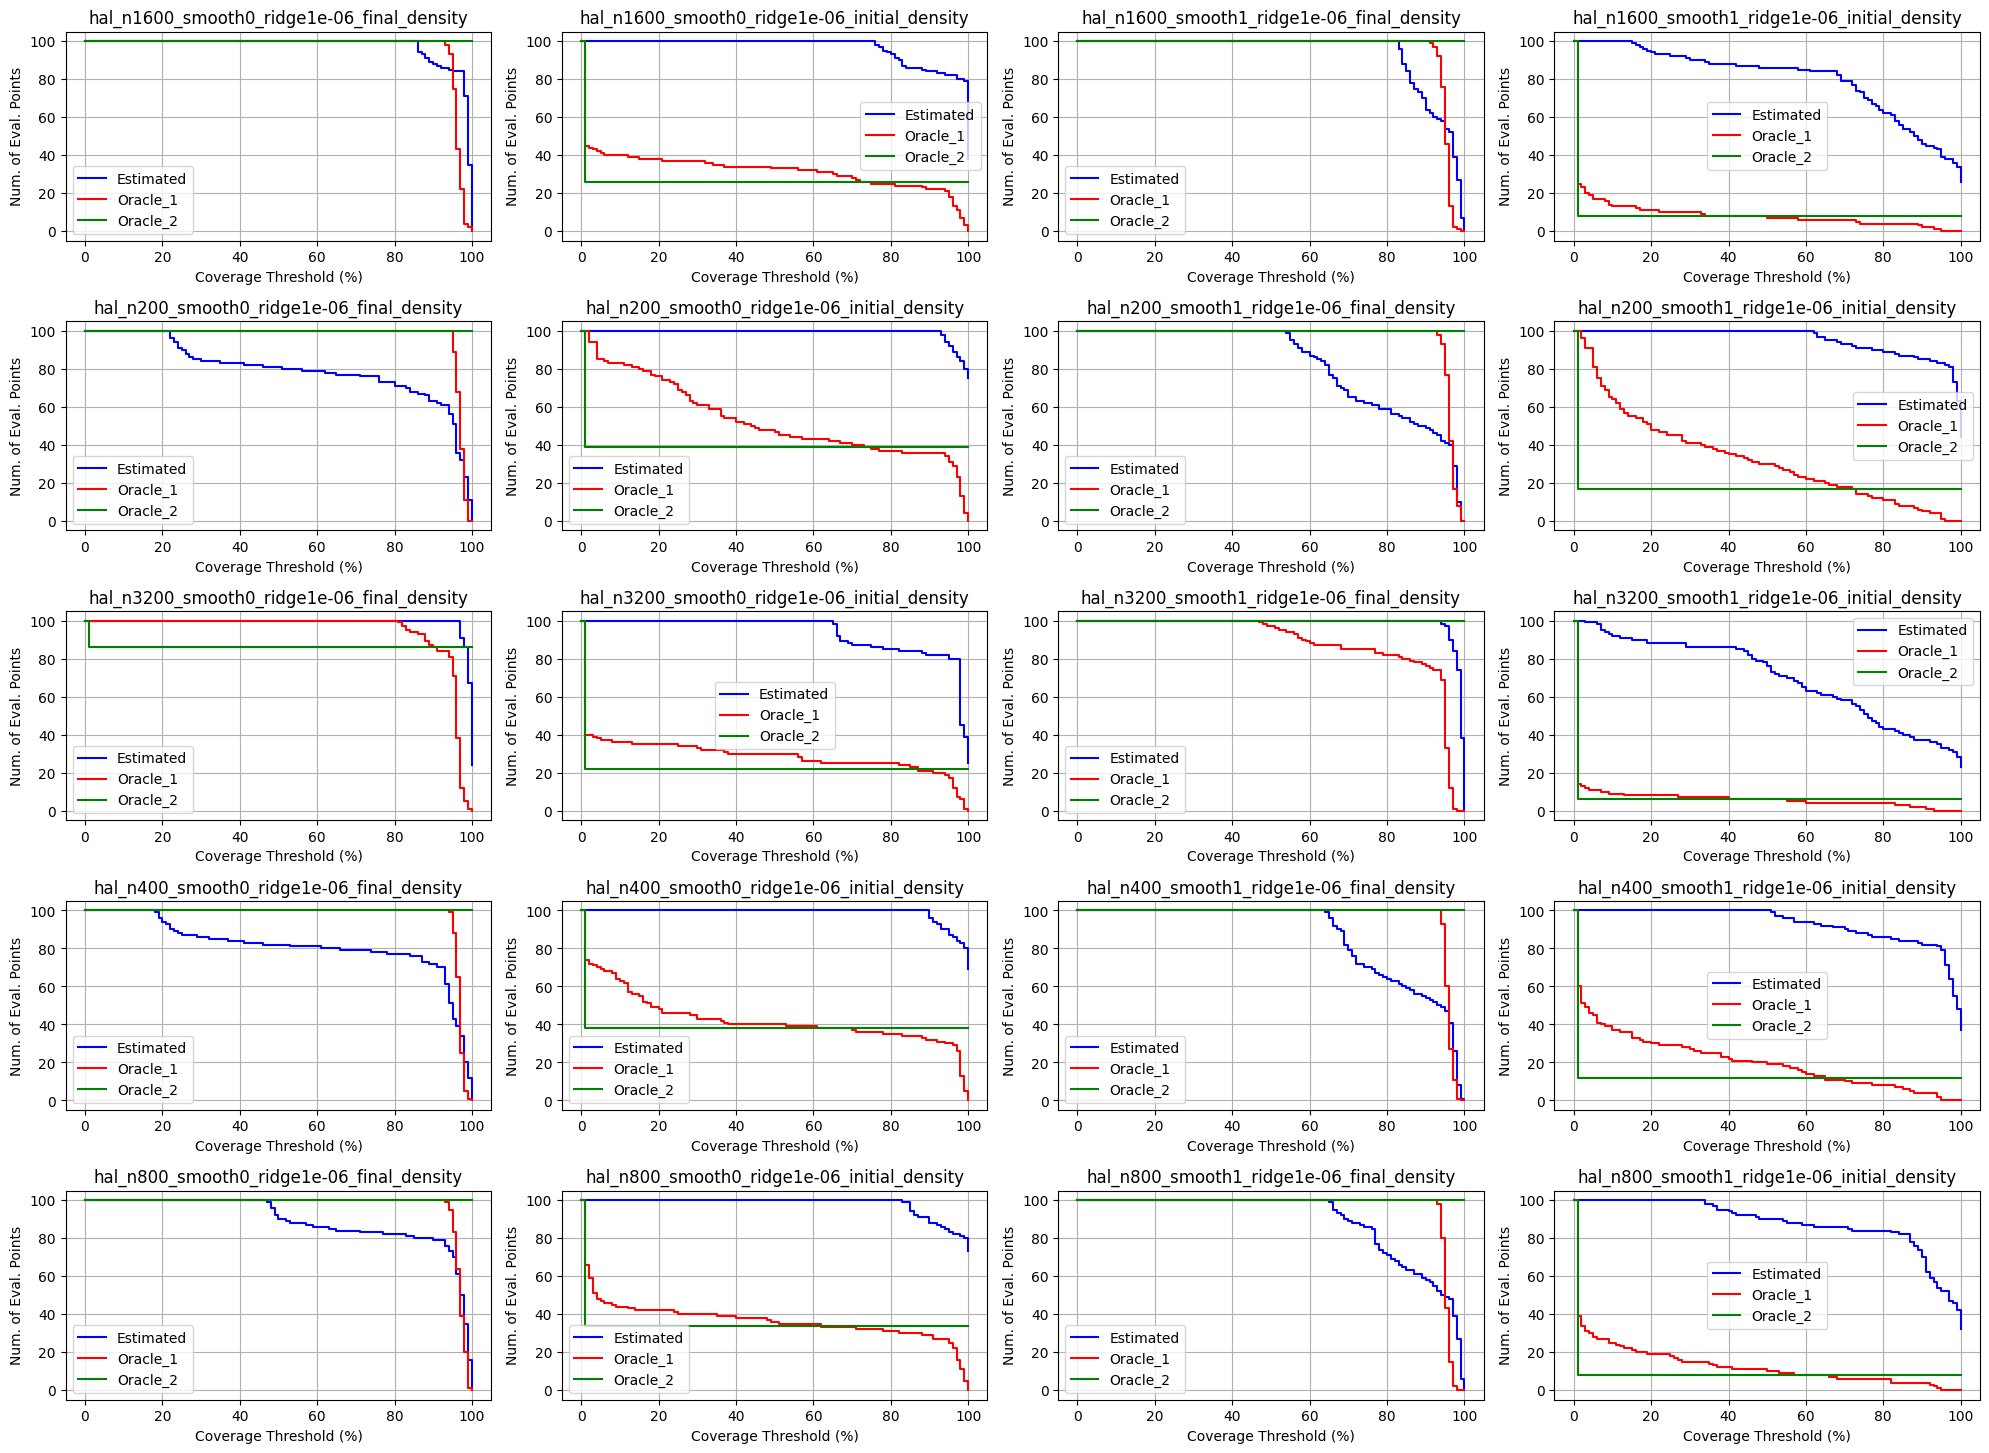

In [39]:
%pip install scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# -------------------------------
# Define the function to compute the true density
def compute_true_density(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    """
    Compute the true density of a truncated normal distribution over given grid points.
    """
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.pdf(grid_points, a, b, loc=mean, scale=std)

# -------------------------------
# 1. Compute Estimated Coverage (using _density and _density_se files)
coverage_results = {}

for key in dataframes.keys():
    # Select files ending with '_density' (but not those ending with '_density_se')
    if key.endswith('_density') and not key.endswith('_density_se'):
        base_name = key
        se_key = base_name + '_se'  # corresponding standard error file

        if se_key in dataframes:
            density_df = dataframes[base_name]
            se_df = dataframes[se_key]

            # Assume the first column contains the evaluation (grid) points
            evaluation_points = density_df.iloc[:, 0].values
            # Compute the true density at these evaluation points
            true_density = compute_true_density(evaluation_points)

            # List to store the empirical (estimated) coverage (in %) for each evaluation point
            coverage_proportions = []
            for i in range(len(evaluation_points)):
                # For each evaluation point, extract the 200 experiments (skip first column)
                point_estimates = density_df.iloc[i, 1:].astype(float).values
                standard_errors = se_df.iloc[i, 1:].astype(float).values

                # Construct the 95% CI for each experiment using 1.96 * SE
                lower_bounds = point_estimates - 1.96 * standard_errors
                upper_bounds = point_estimates + 1.96 * standard_errors

                true_val = true_density[i]
                within_CI = (lower_bounds <= true_val) & (true_val <= upper_bounds)
                coverage = np.mean(within_CI) * 100  # percentage coverage
                coverage_proportions.append(coverage)

            # Store results in a DataFrame for later plotting
            coverage_df = pd.DataFrame({
                'Evaluation Point': evaluation_points,
                'True Density': true_density,
                'Coverage (%)': coverage_proportions
            })
            coverage_results[base_name] = coverage_df

# -------------------------------
# 2. Compute Oracle_1 Coverage (using only the _density file)
oracle_coverage_results = {}

for key in dataframes.keys():
    if key.endswith('_density') and not key.endswith('_density_se'):
        base_name = key
        density_df = dataframes[base_name]

        # Assume the first column contains the evaluation (grid) points
        evaluation_points = density_df.iloc[:, 0].values
        true_density = compute_true_density(evaluation_points)

        oracle_coverage_proportions = []
        for i in range(len(evaluation_points)):
            # Extract the 200 experiment estimates (skip first column)
            point_estimates = density_df.iloc[i, 1:].astype(float).values
            # Compute the oracle standard error as the sample standard deviation (ddof=1)
            oracle_se = np.std(point_estimates, ddof=1)
            # Construct the 95% CI for each experiment using oracle_se
            lower_bounds = point_estimates - 1.96 * oracle_se
            upper_bounds = point_estimates + 1.96 * oracle_se

            true_val = true_density[i]
            within_CI = (lower_bounds <= true_val) & (true_val <= upper_bounds)
            oracle_cov = np.mean(within_CI) * 100  # as a percentage
            oracle_coverage_proportions.append(oracle_cov)

        oracle_coverage_df = pd.DataFrame({
            'Evaluation Point': evaluation_points,
            'True Density': true_density,
            'Oracle Coverage (%)': oracle_coverage_proportions
        })
        oracle_coverage_results[base_name] = oracle_coverage_df

        # Optional: print for inspection
        print(f"Oracle_1 Coverage results for {base_name}:")
        print(oracle_coverage_df, "\n")

# -------------------------------
# 3. Compute Oracle_2 Coverage (quantile-based CI)
# For each evaluation point, we use the 200 experiment estimates to form a single quantile-based CI.
oracle_2_coverage_results = {}

for key in dataframes.keys():
    if key.endswith('_density') and not key.endswith('_density_se'):
        base_name = key
        density_df = dataframes[base_name]
        evaluation_points = density_df.iloc[:, 0].values
        true_density = compute_true_density(evaluation_points)

        oracle2_coverage_proportions = []
        for i in range(len(evaluation_points)):
            # Extract the 200 experiment estimates (skip first column)
            point_estimates = density_df.iloc[i, 1:].astype(float).values

            # Use the mean as the center (psi_n) and the sample std as sigma_n
            psi_n = np.mean(point_estimates)
            sigma_n = np.std(point_estimates, ddof=1)

            # Standardize the estimates
            z_vals = (point_estimates - psi_n) / sigma_n
            # Get the 2.5th and 97.5th percentiles of the standardized values
            q_lower = np.percentile(z_vals, 2.5)
            q_upper = np.percentile(z_vals, 97.5)
            # Construct the quantile-based CI
            lower_bound = psi_n + q_lower * sigma_n
            upper_bound = psi_n + q_upper * sigma_n

            true_val = true_density[i]
            # Here, we have one interval per evaluation point. Coverage is 100 if the true value is in the CI, else 0.
            coverage = 100 if (lower_bound <= true_val <= upper_bound) else 0
            oracle2_coverage_proportions.append(coverage)

        oracle2_df = pd.DataFrame({
            'Evaluation Point': evaluation_points,
            'True Density': true_density,
            'Oracle_2 Coverage (%)': oracle2_coverage_proportions
        })
        oracle_2_coverage_results[base_name] = oracle2_df

        # Optional: print for inspection
        print(f"Oracle_2 Coverage results for {base_name}:")
        print(oracle2_df, "\n")

# -------------------------------
# 4. Plot Survival Curves for Estimated, Oracle_1, and Oracle_2 Together
# For each file pair, we count (over evaluation points) how many have a coverage percentage
# above a grid of thresholds (from 0% to 100%).

# Get a sorted list of file pair names (base names) for which coverage was computed
file_pair_names = sorted(list(coverage_results.keys()))
n_pairs = len(file_pair_names)

# Define a fine grid of coverage thresholds from 0% to 100%
thresholds = np.linspace(0, 100, 101)

# Set up a 4x4 grid for survival plot comparisons
nrows, ncols = 7, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_pair_names):
    ax = axes[idx]

    # Retrieve the DataFrames for this file pair.
    estimated_df = coverage_results[base_name]
    oracle1_df   = oracle_coverage_results[base_name]
    oracle2_df   = oracle_2_coverage_results[base_name]

    # Extract the coverage percentages.
    estimated_values = estimated_df['Coverage (%)'].values
    oracle1_values   = oracle1_df['Oracle Coverage (%)'].values
    oracle2_values   = oracle2_df['Oracle_2 Coverage (%)'].values

    # For each threshold, count how many evaluation points have coverage >= threshold.
    estimated_survival = [np.sum(estimated_values >= thr) for thr in thresholds]
    oracle1_survival   = [np.sum(oracle1_values   >= thr) for thr in thresholds]
    oracle2_survival   = [np.sum(oracle2_values   >= thr) for thr in thresholds]

    # Plot the survival curves using step plots
    ax.step(thresholds, estimated_survival, where='post', label='Estimated', color='blue')
    ax.step(thresholds, oracle1_survival,   where='post', label='Oracle_1', color='red')
    ax.step(thresholds, oracle2_survival,   where='post', label='Oracle_2', color='green')

    ax.set_title(base_name)
    ax.set_xlabel('Coverage Threshold (%)')
    ax.set_ylabel('Num. of Eval. Points')
    ax.legend()
    ax.grid(True)

# Remove extra subplots if there are fewer than 16 file pairs
for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


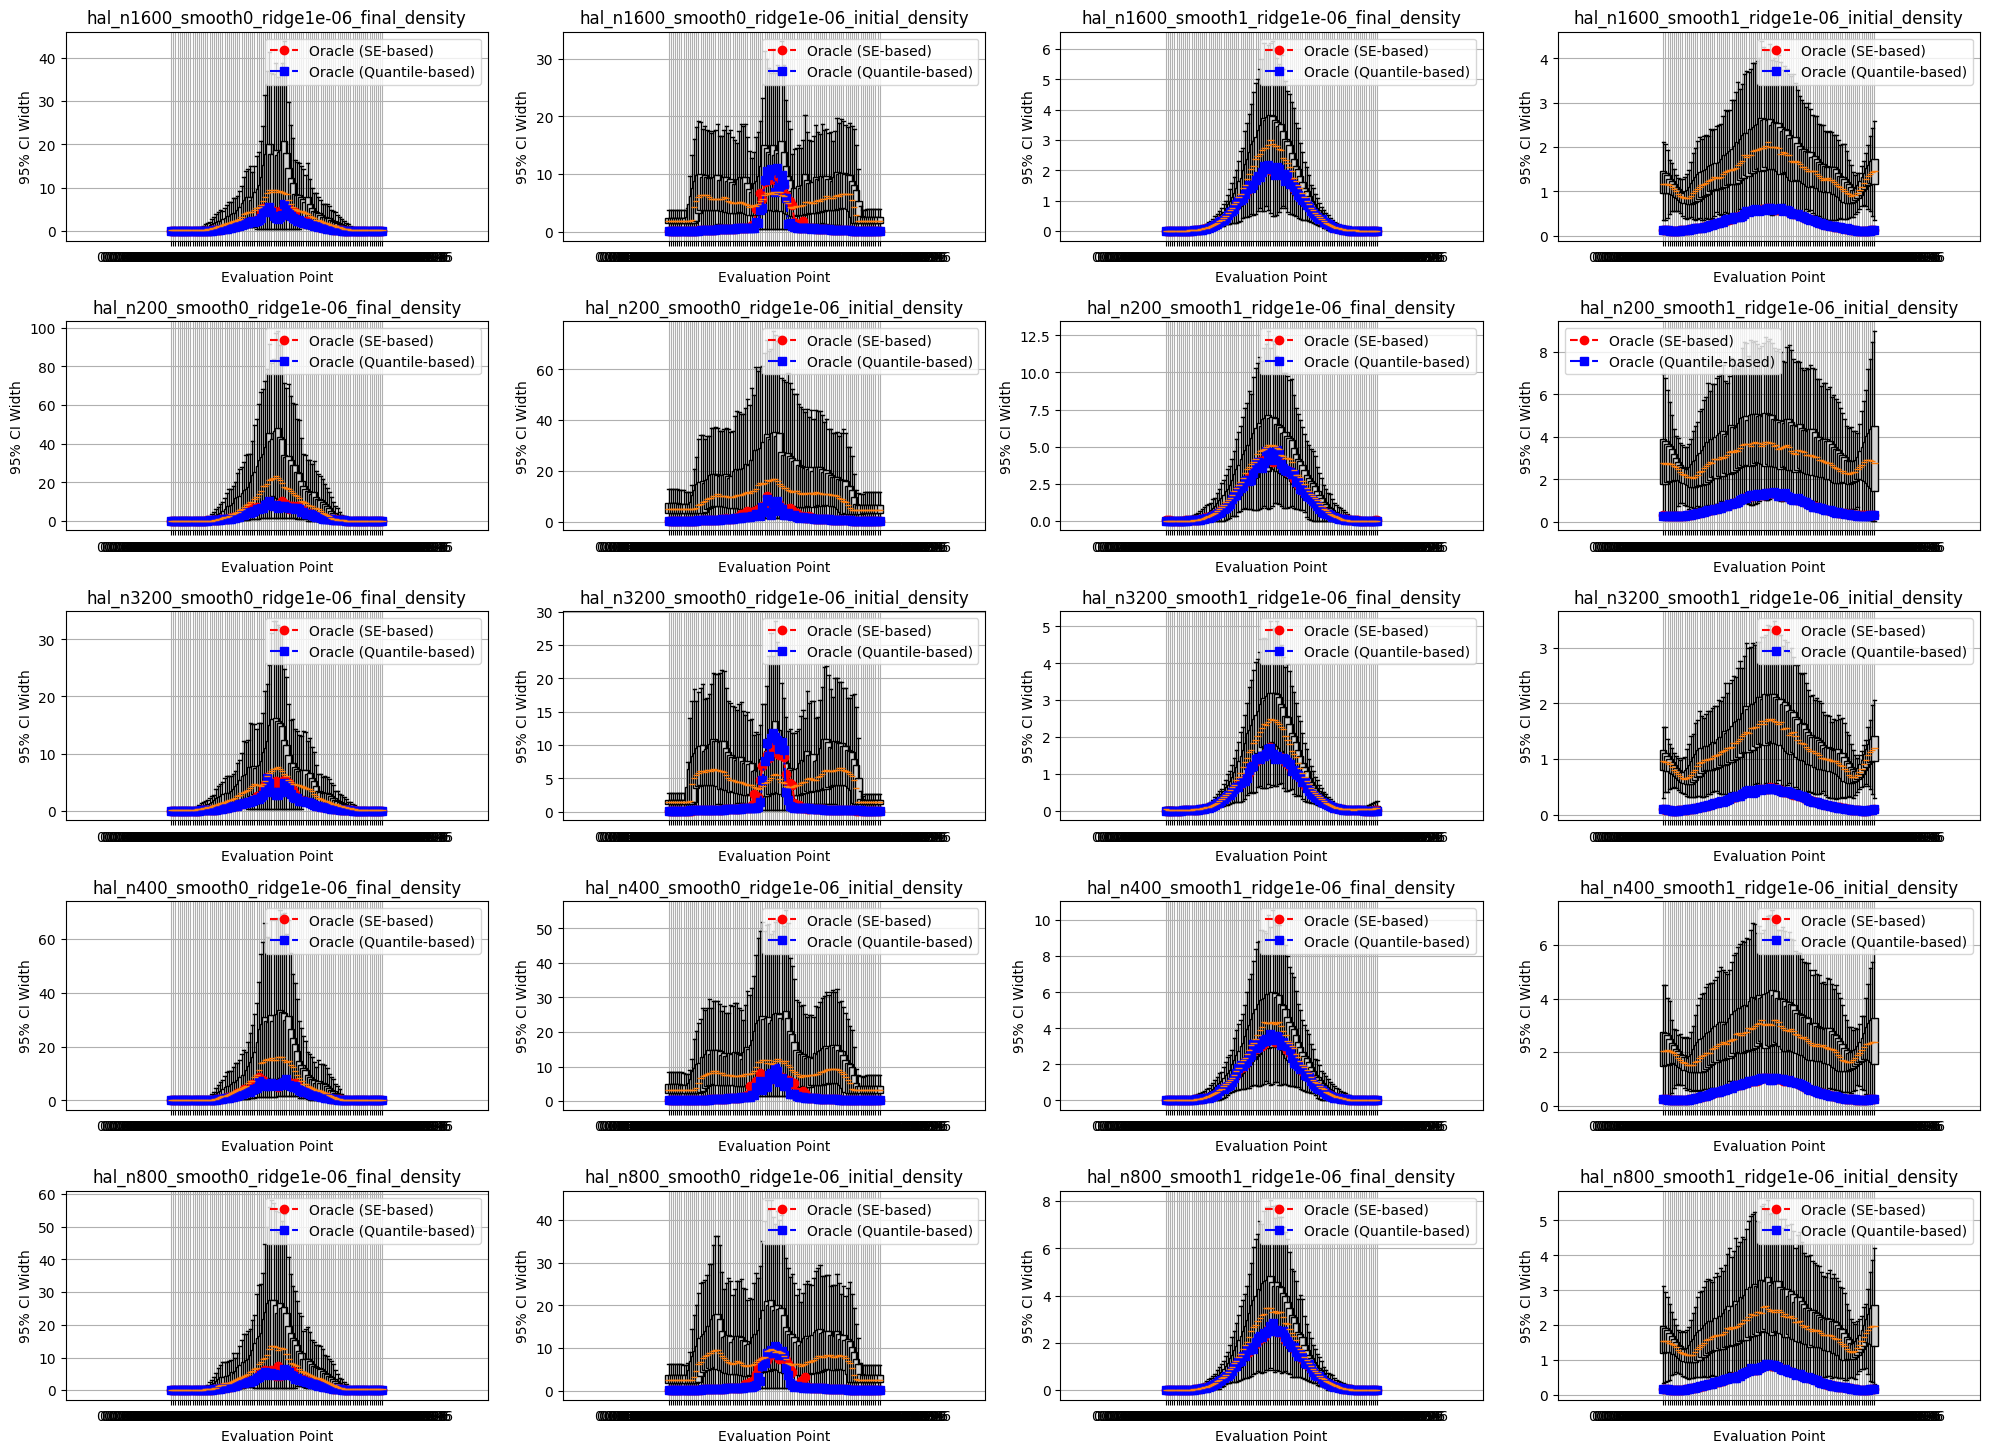

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We'll collect the CI width data and the two oracle estimates for each file pair.
ci_width_results = {}

for key in dataframes.keys():
    # Look for keys that end with '_density' (but not '_density_se')
    if key.endswith('_density') and not key.endswith('_density_se'):
        base_name = key
        se_key = base_name + '_se'
        if se_key in dataframes:
            density_df = dataframes[base_name]
            se_df = dataframes[se_key]

            # Assume the first column holds the evaluation (grid) points
            eval_points = density_df.iloc[:, 0].values

            # Prepare lists to store data for each evaluation point
            boxplot_data = []      # List of arrays: one array per evaluation point (CI widths across experiments)
            oracle_widths1 = []    # Oracle CI widths based on the sample standard deviation (SE-based)
            oracle_widths2 = []    # Oracle CI widths based on the quantile-based method

            # Loop over evaluation points (each row)
            for i in range(len(eval_points)):
                # -- From the _density_se file: Compute CI widths for each experiment
                se_values = se_df.iloc[i, 1:].astype(float).values
                ci_widths = 2 * 1.96 * se_values
                boxplot_data.append(ci_widths)

                # -- From the _density file: Get the point estimates for this evaluation point
                point_estimates = density_df.iloc[i, 1:].astype(float).values

                # Oracle Method 1: SE-based oracle
                oracle_se = np.std(point_estimates, ddof=1)
                oracle_ci_width1 = 2 * 1.96 * oracle_se
                oracle_widths1.append(oracle_ci_width1)

                # Oracle Method 2: Quantile-based oracle
                # First, compute the mean and std (psi_n and sigma_n)
                psi_n = np.mean(point_estimates)
                sigma_n = np.std(point_estimates, ddof=1)
                # Standardize the estimates
                z_vals = (point_estimates - psi_n) / sigma_n
                # Get the 2.5th and 97.5th percentiles of the standardized values
                q_lower = np.percentile(z_vals, 2.5)
                q_upper = np.percentile(z_vals, 97.5)
                # The CI width is sigma_n times the difference in quantiles
                oracle_ci_width2 = sigma_n * (q_upper - q_lower)
                oracle_widths2.append(oracle_ci_width2)

            # Save the computed results for this file pair.
            ci_width_results[base_name] = {
                'eval_points': eval_points,
                'boxplot_data': boxplot_data,
                'oracle_widths1': oracle_widths1,
                'oracle_widths2': oracle_widths2
            }

# ---
# Now plot the results in a 4x4 grid.
file_names = sorted(ci_width_results.keys())
n_files = len(file_names)
nrows, ncols = 7, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_names):
    ax = axes[idx]
    res = ci_width_results[base_name]
    eval_points = res['eval_points']
    box_data = res['boxplot_data']
    oracle1 = res['oracle_widths1']
    oracle2 = res['oracle_widths2']

    # Create the boxplot.
    # We'll use the evaluation points as the positions.
    bp = ax.boxplot(box_data, positions=eval_points, widths=0.03, patch_artist=True, showfliers=False)

    # Customize the boxplot (optional)
    for box in bp['boxes']:
        box.set(facecolor='lightgray')

    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("95% CI Width")

    # Overlay the oracle estimates as lines.
    ax.plot(eval_points, oracle1, color='red', linestyle='--', marker='o', label='Oracle (SE-based)')
    ax.plot(eval_points, oracle2, color='blue', linestyle='-.', marker='s', label='Oracle (Quantile-based)')
    ax.legend()
    ax.grid(True)

# Remove any extra subplots if there are fewer than 16 file pairs.
for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


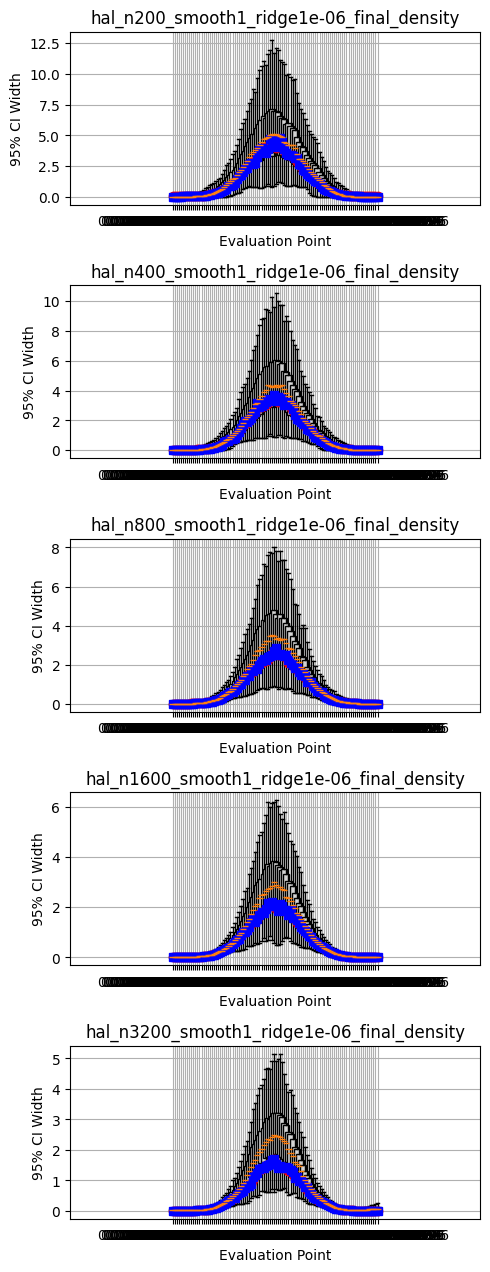

In [40]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filter for keys that correspond to smooth order 1 and final survival results.
ci_width_results = {}

for key in dataframes.keys():
    # We only want keys that end with '_survival' (and not '_survival_se') and contain 'smooth1'
    if key.endswith('final_density') and not key.endswith('_density_se') and "smooth1" in key:
        base_name = key
        se_key = base_name + '_se'
        if se_key in dataframes:
            survival_df = dataframes[base_name]
            se_df = dataframes[se_key]

            # Assume the first column holds the evaluation (grid) points.
            eval_points = survival_df.iloc[:, 0].values

            boxplot_data = []      # List of arrays: one array per evaluation point (CI widths across experiments)
            oracle_widths1 = []    # Oracle CI widths based on the sample standard deviation (SE-based)
            oracle_widths2 = []    # Oracle CI widths based on the quantile-based method

            for i in range(len(eval_points)):
                se_values = se_df.iloc[i, 1:].astype(float).values
                ci_widths = 2 * 1.96 * se_values
                boxplot_data.append(ci_widths)

                point_estimates = survival_df.iloc[i, 1:].astype(float).values

                oracle_se = np.std(point_estimates, ddof=1)
                oracle_ci_width1 = 2 * 1.96 * oracle_se
                oracle_widths1.append(oracle_ci_width1)

                psi_n = np.mean(point_estimates)
                sigma_n = np.std(point_estimates, ddof=1)
                z_vals = (point_estimates - psi_n) / sigma_n
                q_lower = np.percentile(z_vals, 2.5)
                q_upper = np.percentile(z_vals, 97.5)
                oracle_ci_width2 = sigma_n * (q_upper - q_lower)
                oracle_widths2.append(oracle_ci_width2)

            ci_width_results[base_name] = {
                'eval_points': eval_points,
                'boxplot_data': boxplot_data,
                'oracle_widths1': oracle_widths1,
                'oracle_widths2': oracle_widths2
            }

# Define a helper function to extract sample size from the key.
def extract_sample_size(key):
    match = re.search(r"hal_n(\d+)_", key)
    if match:
        return int(match.group(1))
    else:
        return float('inf')

# Filter keys that are in smooth order 1 and sort them by sample size.
file_names = [k for k in ci_width_results.keys() if "smooth1" in k]
file_names = sorted(file_names, key=extract_sample_size)

# Plot the results in an 8x4 grid.
n_files = len(file_names)
nrows, ncols = 8, 1
fig, axes = plt.subplots(nrows, ncols, figsize=(5, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_names):
    ax = axes[idx]
    res = ci_width_results[base_name]
    eval_points = res['eval_points']
    box_data = res['boxplot_data']
    oracle1 = res['oracle_widths1']
    oracle2 = res['oracle_widths2']

    bp = ax.boxplot(box_data, positions=eval_points, widths=0.03, patch_artist=True, showfliers=False)
    for box in bp['boxes']:
        box.set(facecolor='lightgray')

    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("95% CI Width")
    ax.plot(eval_points, oracle1, color='red', linestyle='--', marker='o', label='Oracle (SE-based)')
    ax.plot(eval_points, oracle2, color='blue', linestyle='-.', marker='s', label='Oracle (Quantile-based)')
    #ax.legend()
    ax.grid(True)

for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Reading file: hal_n200_smooth1_ridge1e-06_final_density.csv
Reading file: hal_n400_smooth1_ridge1e-06_final_density.csv
Reading file: hal_n1600_smooth1_ridge1e-06_final_density.csv
Reading file: hal_n800_smooth1_ridge1e-06_final_density.csv
Reading file: hal_n3200_smooth0_ridge1e-06_final_density.csv
Reading file: hal_n3200_smooth1_ridge1e-06_final_density.csv
Reading file: hal_n800_smooth0_ridge1e-06_final_density.csv
Reading file: hal_n1600_smooth0_ridge1e-06_final_density.csv
Reading file: hal_n400_smooth0_ridge1e-06_final_density.csv
Reading file: hal_n200_smooth0_ridge1e-06_final_density.csv


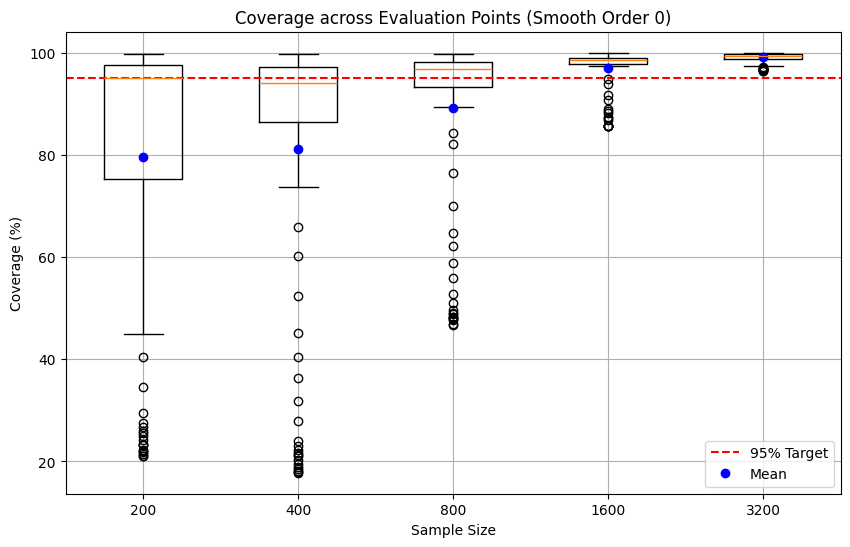

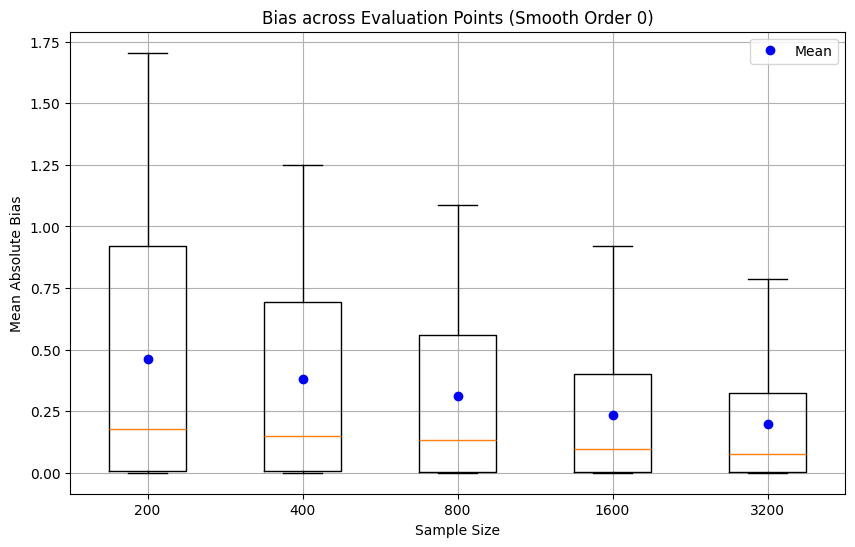

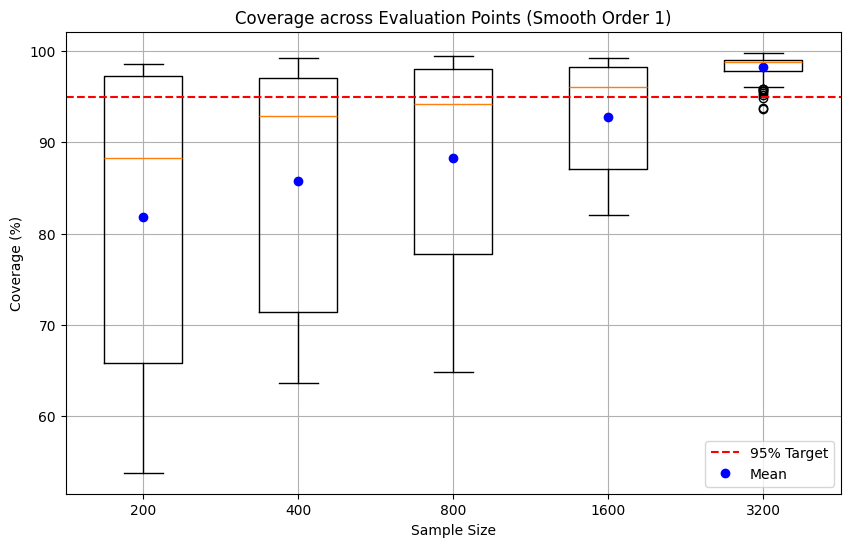

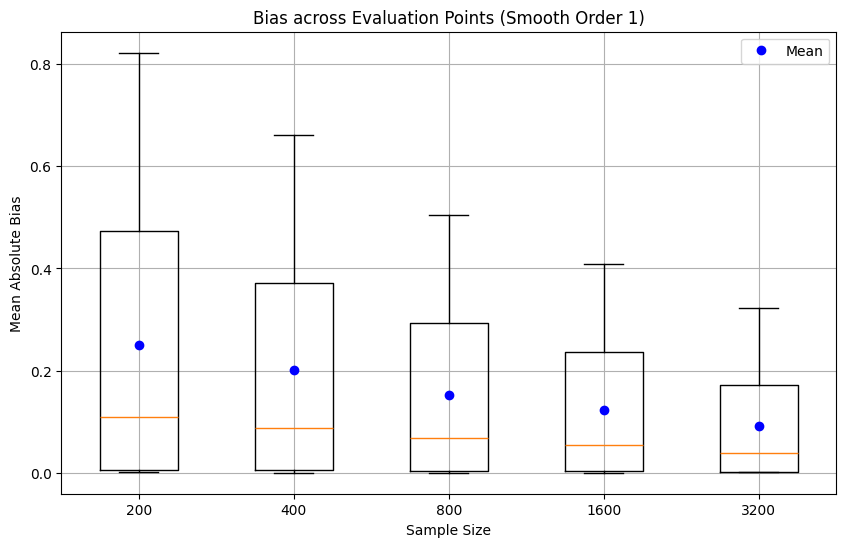

In [33]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm


# Define a function to compute the true density (truncated normal)
def compute_true_density(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.pdf(grid_points, a, b, loc=mean, scale=std)

# Use a regex that extracts both sample size and smooth order.
# For example, file names like "hal_n800_smooth0_..." or "hal_n800_smooth1_..."
density_files = glob.glob(os.path.join(folder_path, "*final_density.csv"))

# Dictionaries to store aggregated pointwise coverage and bias.
# Key: (n_samples, smooth_order)
coverage_data = {}
bias_data = {}

# Loop over each density file
for density_file in density_files:
    basename = os.path.basename(density_file)
    print("Reading file:", basename)
    # Adjust regex to capture sample size and smooth order.
    match = re.search(r"hal_n(\d+)_smooth(\d+)_", basename)
    if not match:
        print("No sample size or smooth order found in:", basename)
        continue
    n_samples = int(match.group(1))
    smooth_order = int(match.group(2))
    key = (n_samples, smooth_order)
    
    # Determine the corresponding standard error file name.
    se_file = density_file.replace("final_density.csv", "final_density_se.csv")
    if not os.path.exists(se_file):
        print(f"SE file not found for {density_file}")
        continue

    # Read CSV files
    density_df = pd.read_csv(density_file)
    se_df = pd.read_csv(se_file)
    
    # Assume first column is the evaluation grid.
    eval_points = density_df.iloc[:, 0].values
    true_density = compute_true_density(eval_points)
    
    # Compute pointwise coverage and bias for each evaluation point.
    coverage_per_eval = []
    bias_per_eval = []
    for i in range(len(eval_points)):
        est_values = density_df.iloc[i, 1:].astype(float).values
        se_values  = se_df.iloc[i, 1:].astype(float).values
        
        # Construct the 95% confidence intervals.
        lower_bounds = est_values - 1.96 * se_values
        upper_bounds = est_values + 1.96 * se_values
        
        # Coverage: percentage of experiments whose CI contains the true density.
        cov_percentage = np.mean((true_density[i] >= lower_bounds) & (true_density[i] <= upper_bounds)) * 100
        coverage_per_eval.append(cov_percentage)
        
        # Bias: mean absolute difference at this evaluation point.
        bias_val = np.mean(np.abs(est_values - true_density[i]))
        bias_per_eval.append(bias_val)
    
    # Aggregate results by (n_samples, smooth_order)
    if key in coverage_data:
        coverage_data[key].extend(coverage_per_eval)
        bias_data[key].extend(bias_per_eval)
    else:
        coverage_data[key] = coverage_per_eval
        bias_data[key] = bias_per_eval

# Now, we want to produce separate graphs for each smooth order.
smooth_orders = sorted(set(s for (_, s) in coverage_data.keys()))

for smooth in smooth_orders:
    # For the current smooth order, extract sample sizes and corresponding groups.
    sample_sizes = sorted(n for (n, s) in coverage_data.keys() if s == smooth)
    # Build lists for the boxplot data.
    coverage_boxplot_data = [coverage_data[(n, smooth)] for n in sample_sizes]
    bias_boxplot_data = [bias_data[(n, smooth)] for n in sample_sizes]
    
    # Plot Coverage for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(coverage_boxplot_data)
    plt.axhline(y=95, color='red', linestyle='--', label='95% Target')
    means_coverage = [np.mean(group) for group in coverage_boxplot_data]
    plt.plot(range(1, len(means_coverage) + 1), means_coverage, marker='o', color='blue', linestyle='None', label='Mean')
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(s) for s in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Coverage (%)")
    plt.title(f"Coverage across Evaluation Points (Smooth Order {smooth})")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Bias for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(bias_boxplot_data)
    means_bias = [np.mean(group) for group in bias_boxplot_data]
    plt.plot(range(1, len(means_bias) + 1), means_bias, marker='o', color='blue', linestyle='None', label='Mean')
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(s) for s in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Mean Absolute Bias")
    plt.title(f"Bias across Evaluation Points (Smooth Order {smooth})")
    plt.legend()
    plt.grid(True)
    plt.show()


Processing: hal_n200_smooth1_ridge1e-06_final_density.csv
Processing: hal_n400_smooth1_ridge1e-06_final_density.csv
Processing: hal_n1600_smooth1_ridge1e-06_final_density.csv
Processing: hal_n800_smooth1_ridge1e-06_final_density.csv
Processing: hal_n3200_smooth0_ridge1e-06_final_density.csv
Processing: hal_n3200_smooth1_ridge1e-06_final_density.csv
Processing: hal_n800_smooth0_ridge1e-06_final_density.csv
Processing: hal_n1600_smooth0_ridge1e-06_final_density.csv
Processing: hal_n400_smooth0_ridge1e-06_final_density.csv
Processing: hal_n200_smooth0_ridge1e-06_final_density.csv


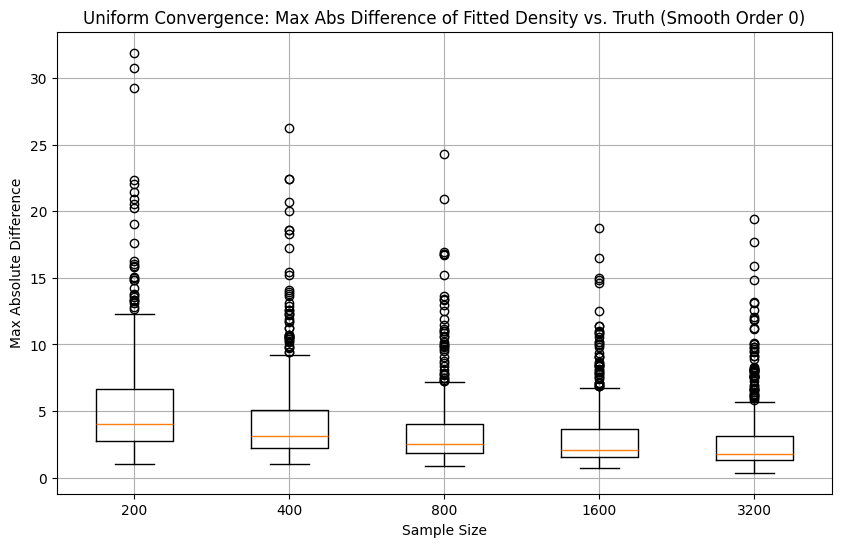

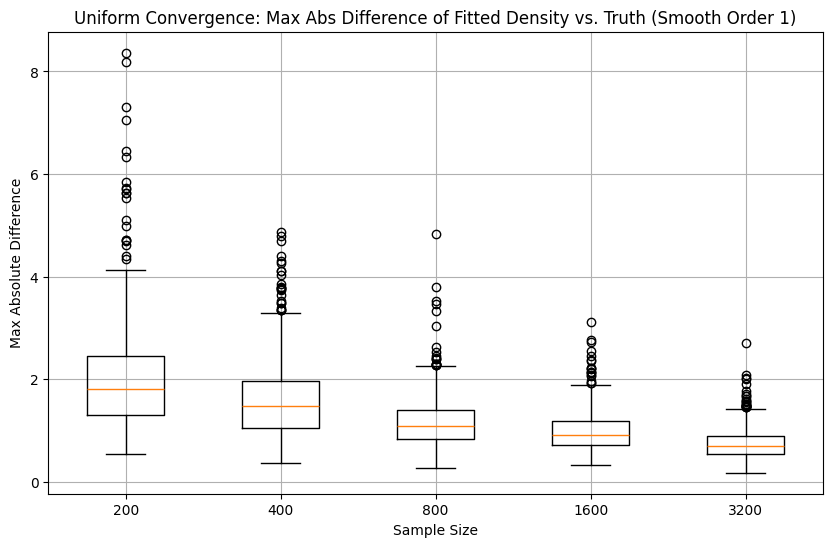

In [34]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# Define a function to compute the true density (truncated normal)
def compute_true_density(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.pdf(grid_points, a, b, loc=mean, scale=std)



# Get all final density CSV files (adjust the pattern if needed)
density_files = glob.glob(os.path.join(folder_path, "*final_density.csv"))

# Dictionary to store the uniform convergence metric for each (sample size, smooth order).
# For each key, we store a list of maximum absolute differences (one per simulation replicate).
uniform_diff_data = {}

# Loop over each density file
for density_file in density_files:
    basename = os.path.basename(density_file)
    print("Processing:", basename)
    # Extract both sample size and smooth order from the file name.
    # Example filename: "hal_n800_smooth0_final_density.csv"
    match = re.search(r"hal_n(\d+)_smooth(\d+)_", basename)
    if not match:
        print("No sample size or smooth order found in:", basename)
        continue
    n_samples = int(match.group(1))
    smooth_order = int(match.group(2))
    key = (n_samples, smooth_order)
    
    # Read the CSV file into a DataFrame
    density_df = pd.read_csv(density_file)
    
    # Assume the first column is the evaluation grid and the rest are simulation experiments.
    eval_points = density_df.iloc[:, 0].values
    true_density = compute_true_density(eval_points)
    
    # For each simulation replicate (each column after the first),
    # calculate the maximum absolute difference between the fitted value and the truth.
    max_diffs = []
    for col in density_df.columns[1:]:
        # Convert the experiment's estimated density to float
        est_values = density_df[col].astype(float).values
        # Compute absolute differences at each evaluation point
        abs_diff = np.abs(est_values - true_density)
        # The uniform error is the maximum absolute difference over the grid
        max_diff = np.max(abs_diff)
        max_diffs.append(max_diff)
    
    # Aggregate the maximum differences by (n_samples, smooth_order)
    if key in uniform_diff_data:
        uniform_diff_data[key].extend(max_diffs)
    else:
        uniform_diff_data[key] = max_diffs

# Now, group the results by smooth order.
smooth_orders = sorted(set(s for (n, s) in uniform_diff_data.keys()))
for smooth in smooth_orders:
    # For the current smooth order, extract the sample sizes and corresponding data.
    sample_sizes = sorted(n for (n, s) in uniform_diff_data.keys() if s == smooth)
    boxplot_data = [uniform_diff_data[(n, smooth)] for n in sample_sizes]
    
    # Plot the box plot for uniform convergence for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(boxplot_data)
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(n) for n in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Max Absolute Difference")
    plt.title(f"Uniform Convergence: Max Abs Difference of Fitted Density vs. Truth (Smooth Order {smooth})")
    plt.grid(True)
    plt.show()


/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/1333039786.py:46: RuntimeWarning: invalid value encountered in divide
  z_vals = (point_estimates - psi_n) / sigma_n
/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/1333039786.py:46: RuntimeWarning: invalid value encountered in divide
  z_vals = (point_estimates - psi_n) / sigma_n
/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/1333039786.py:46: RuntimeWarning: invalid value encountered in divide
  z_vals = (point_estimates - psi_n) / sigma_n
/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/1333039786.py:46: RuntimeWarning: invalid value encountered in divide
  z_vals = (point_estimates - psi_n) / sigma_n
/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/1333039786.py:46: RuntimeWarning: invalid value encountered in divide
  z_vals = (point_estimates - psi_n) / sigma_n
/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/1333039786.py:46: RuntimeWarnin

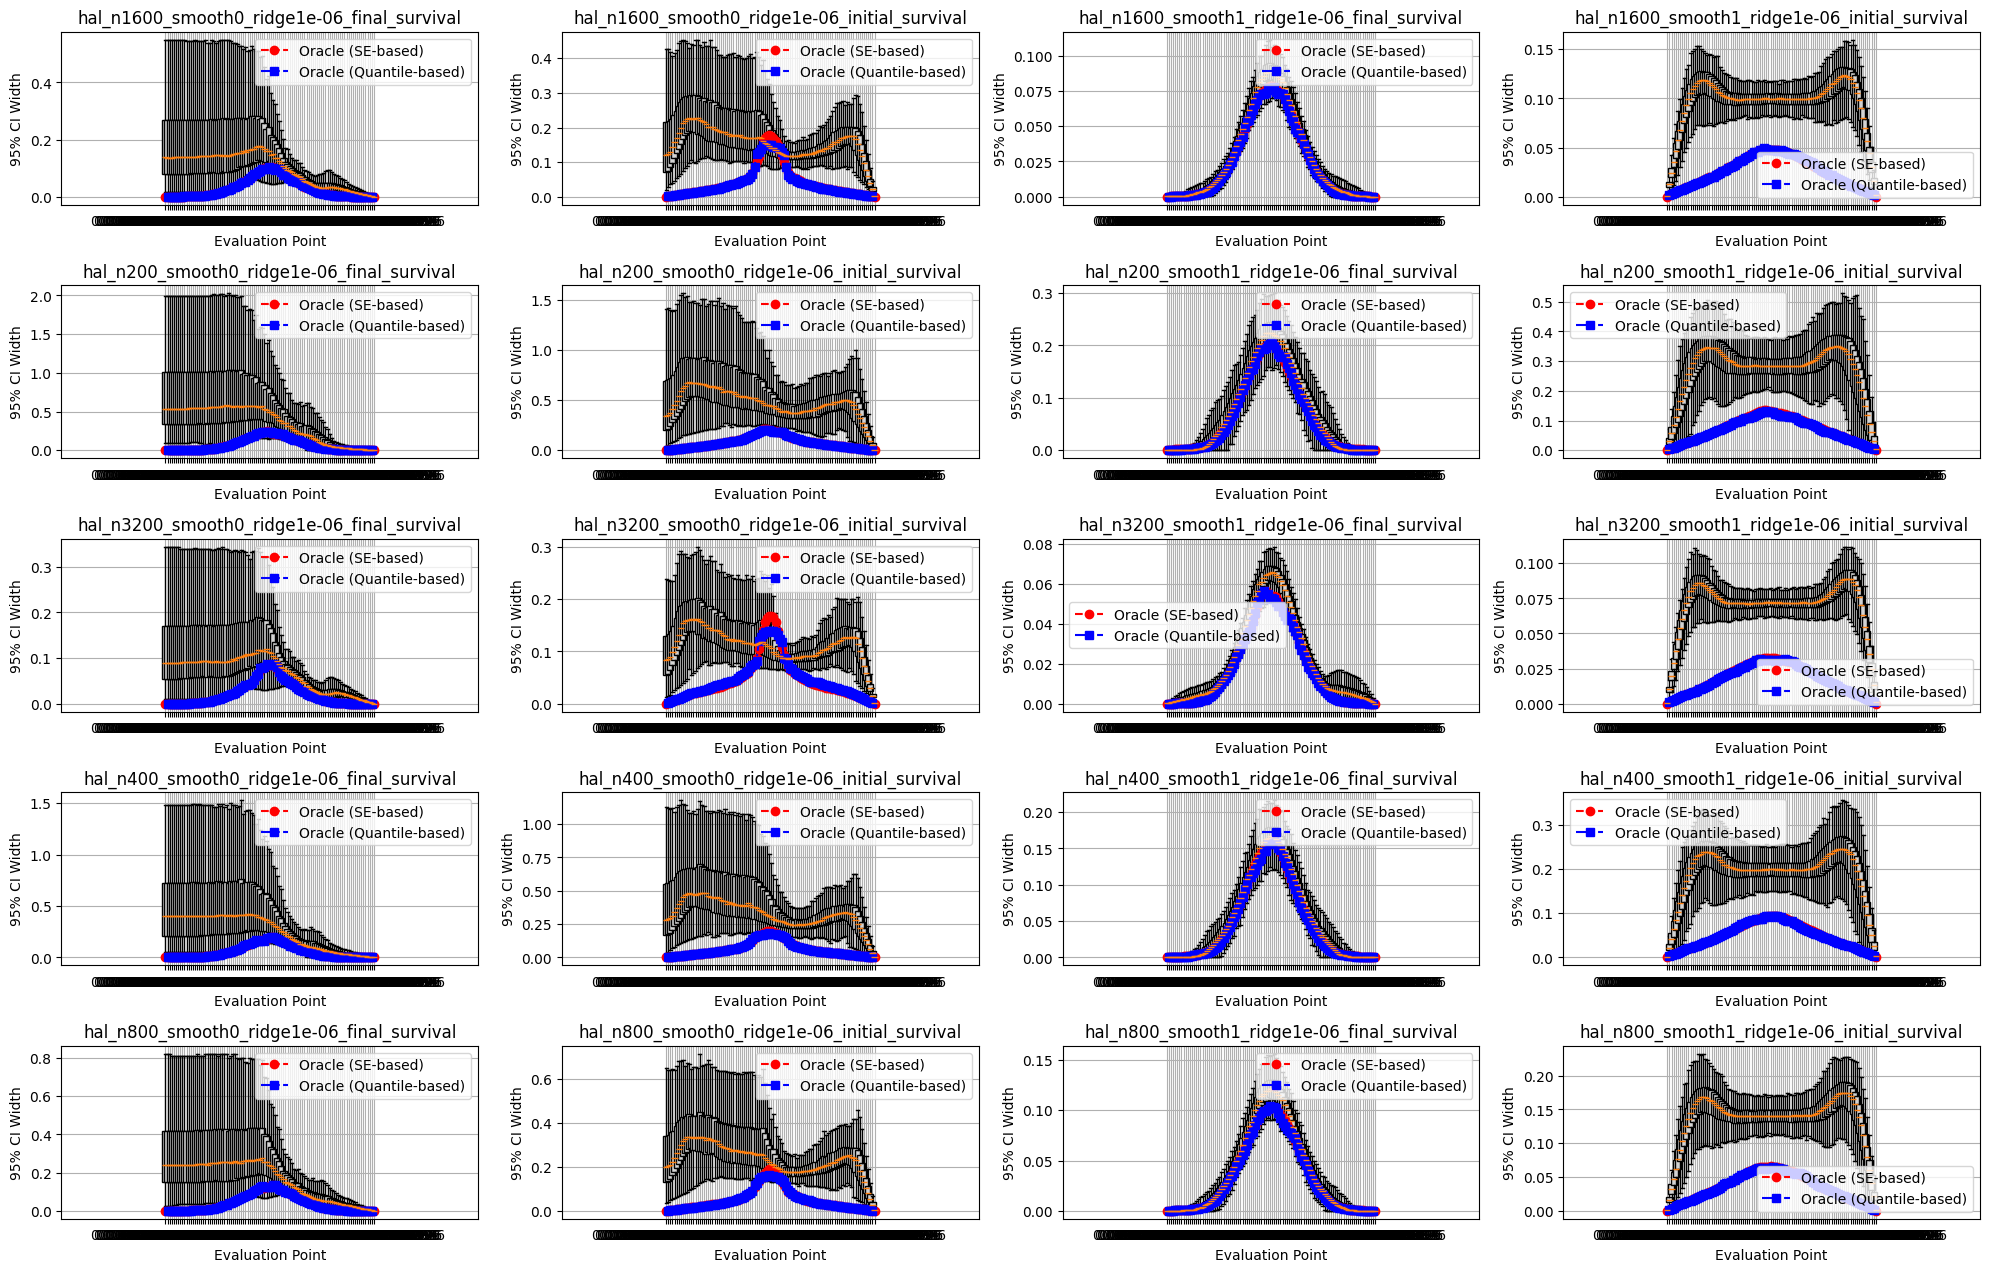

In [18]:
# Note to change the variable name form density to survival
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We'll collect the CI width data and the two oracle estimates for each file pair.
ci_width_results = {}

for key in dataframes.keys():
    # Look for keys that end with '_density' (but not '_density_se')
    if key.endswith('_survival') and not key.endswith('_survival_se'):
        base_name = key
        se_key = base_name + '_se'
        if se_key in dataframes:
            density_df = dataframes[base_name]
            se_df = dataframes[se_key]

            # Assume the first column holds the evaluation (grid) points
            eval_points = density_df.iloc[:, 0].values

            # Prepare lists to store data for each evaluation point
            boxplot_data = []      # List of arrays: one array per evaluation point (CI widths across experiments)
            oracle_widths1 = []    # Oracle CI widths based on the sample standard deviation (SE-based)
            oracle_widths2 = []    # Oracle CI widths based on the quantile-based method

            # Loop over evaluation points (each row)
            for i in range(len(eval_points)):
                # -- From the _density_se file: Compute CI widths for each experiment
                se_values = se_df.iloc[i, 1:].astype(float).values
                ci_widths = 2 * 1.96 * se_values
                boxplot_data.append(ci_widths)

                # -- From the _density file: Get the point estimates for this evaluation point
                point_estimates = density_df.iloc[i, 1:].astype(float).values

                # Oracle Method 1: SE-based oracle
                oracle_se = np.std(point_estimates, ddof=1)
                oracle_ci_width1 = 2 * 1.96 * oracle_se
                oracle_widths1.append(oracle_ci_width1)

                # Oracle Method 2: Quantile-based oracle
                # First, compute the mean and std (psi_n and sigma_n)
                psi_n = np.mean(point_estimates)
                sigma_n = np.std(point_estimates, ddof=1)
                # Standardize the estimates
                z_vals = (point_estimates - psi_n) / sigma_n
                # Get the 2.5th and 97.5th percentiles of the standardized values
                q_lower = np.percentile(z_vals, 2.5)
                q_upper = np.percentile(z_vals, 97.5)
                # The CI width is sigma_n times the difference in quantiles
                oracle_ci_width2 = sigma_n * (q_upper - q_lower)
                oracle_widths2.append(oracle_ci_width2)

            # Save the computed results for this file pair.
            ci_width_results[base_name] = {
                'eval_points': eval_points,
                'boxplot_data': boxplot_data,
                'oracle_widths1': oracle_widths1,
                'oracle_widths2': oracle_widths2
            }

# ---
# Now plot the results in a 4x4 grid.
file_names = sorted(ci_width_results.keys())
n_files = len(file_names)
nrows, ncols = 8, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_names):
    ax = axes[idx]
    res = ci_width_results[base_name]
    eval_points = res['eval_points']
    box_data = res['boxplot_data']
    oracle1 = res['oracle_widths1']
    oracle2 = res['oracle_widths2']

    # Create the boxplot.
    # We'll use the evaluation points as the positions.
    bp = ax.boxplot(box_data, positions=eval_points, widths=0.03, patch_artist=True, showfliers=False)

    # Customize the boxplot (optional)
    for box in bp['boxes']:
        box.set(facecolor='lightgray')

    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("95% CI Width")

    # Overlay the oracle estimates as lines.
    ax.plot(eval_points, oracle1, color='red', linestyle='--', marker='o', label='Oracle (SE-based)')
    ax.plot(eval_points, oracle2, color='blue', linestyle='-.', marker='s', label='Oracle (Quantile-based)')
    ax.legend()
    ax.grid(True)

# Remove any extra subplots if there are fewer than 16 file pairs.
for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/799329006.py:38: RuntimeWarning: invalid value encountered in divide
  z_vals = (point_estimates - psi_n) / sigma_n
/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/799329006.py:38: RuntimeWarning: invalid value encountered in divide
  z_vals = (point_estimates - psi_n) / sigma_n
/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/799329006.py:38: RuntimeWarning: invalid value encountered in divide
  z_vals = (point_estimates - psi_n) / sigma_n
/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/799329006.py:38: RuntimeWarning: invalid value encountered in divide
  z_vals = (point_estimates - psi_n) / sigma_n
/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/799329006.py:38: RuntimeWarning: invalid value encountered in divide
  z_vals = (point_estimates - psi_n) / sigma_n
/var/folders/65/x30mj4jd3wb_rz8hlyy732_m0000gn/T/ipykernel_2370/799329006.py:38: RuntimeWarning: inv

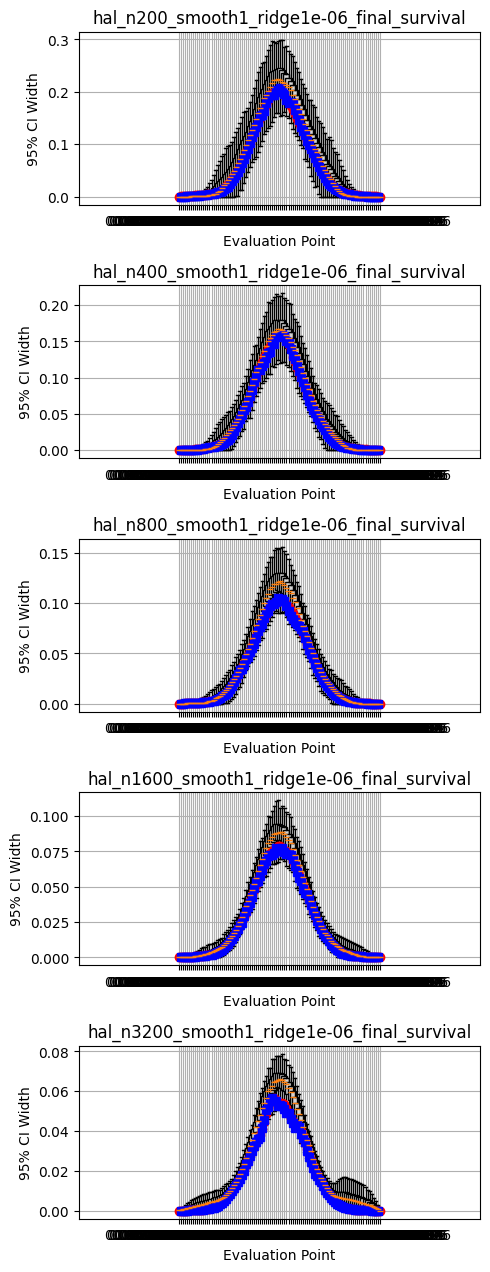

In [23]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filter for keys that correspond to smooth order 1 and final survival results.
ci_width_results = {}

for key in dataframes.keys():
    # We only want keys that end with '_survival' (and not '_survival_se') and contain 'smooth1'
    if key.endswith('final_survival') and not key.endswith('_survival_se') and "smooth1" in key:
        base_name = key
        se_key = base_name + '_se'
        if se_key in dataframes:
            survival_df = dataframes[base_name]
            se_df = dataframes[se_key]

            # Assume the first column holds the evaluation (grid) points.
            eval_points = survival_df.iloc[:, 0].values

            boxplot_data = []      # List of arrays: one array per evaluation point (CI widths across experiments)
            oracle_widths1 = []    # Oracle CI widths based on the sample standard deviation (SE-based)
            oracle_widths2 = []    # Oracle CI widths based on the quantile-based method

            for i in range(len(eval_points)):
                se_values = se_df.iloc[i, 1:].astype(float).values
                ci_widths = 2 * 1.96 * se_values
                boxplot_data.append(ci_widths)

                point_estimates = survival_df.iloc[i, 1:].astype(float).values

                oracle_se = np.std(point_estimates, ddof=1)
                oracle_ci_width1 = 2 * 1.96 * oracle_se
                oracle_widths1.append(oracle_ci_width1)

                psi_n = np.mean(point_estimates)
                sigma_n = np.std(point_estimates, ddof=1)
                z_vals = (point_estimates - psi_n) / sigma_n
                q_lower = np.percentile(z_vals, 2.5)
                q_upper = np.percentile(z_vals, 97.5)
                oracle_ci_width2 = sigma_n * (q_upper - q_lower)
                oracle_widths2.append(oracle_ci_width2)

            ci_width_results[base_name] = {
                'eval_points': eval_points,
                'boxplot_data': boxplot_data,
                'oracle_widths1': oracle_widths1,
                'oracle_widths2': oracle_widths2
            }

# Define a helper function to extract sample size from the key.
def extract_sample_size(key):
    match = re.search(r"hal_n(\d+)_", key)
    if match:
        return int(match.group(1))
    else:
        return float('inf')

# Filter keys that are in smooth order 1 and sort them by sample size.
file_names = [k for k in ci_width_results.keys() if "smooth1" in k]
file_names = sorted(file_names, key=extract_sample_size)

# Plot the results in an 8x4 grid.
n_files = len(file_names)
nrows, ncols = 8, 1
fig, axes = plt.subplots(nrows, ncols, figsize=(5, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_names):
    ax = axes[idx]
    res = ci_width_results[base_name]
    eval_points = res['eval_points']
    box_data = res['boxplot_data']
    oracle1 = res['oracle_widths1']
    oracle2 = res['oracle_widths2']

    bp = ax.boxplot(box_data, positions=eval_points, widths=0.03, patch_artist=True, showfliers=False)
    for box in bp['boxes']:
        box.set(facecolor='lightgray')

    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("95% CI Width")
    ax.plot(eval_points, oracle1, color='red', linestyle='--', marker='o', label='Oracle (SE-based)')
    ax.plot(eval_points, oracle2, color='blue', linestyle='-.', marker='s', label='Oracle (Quantile-based)')
    #ax.legend()
    ax.grid(True)

for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Reading file: hal_n1600_smooth1_ridge1e-06_final_survival.csv
Reading file: hal_n1600_smooth0_ridge1e-06_final_survival.csv
Reading file: hal_n800_smooth1_ridge1e-06_final_survival.csv
Reading file: hal_n200_smooth0_ridge1e-06_final_survival.csv
Reading file: hal_n3200_smooth1_ridge1e-06_final_survival.csv
Reading file: hal_n400_smooth1_ridge1e-06_final_survival.csv
Reading file: hal_n800_smooth0_ridge1e-06_final_survival.csv
Reading file: hal_n400_smooth0_ridge1e-06_final_survival.csv
Reading file: hal_n3200_smooth0_ridge1e-06_final_survival.csv
Reading file: hal_n200_smooth1_ridge1e-06_final_survival.csv


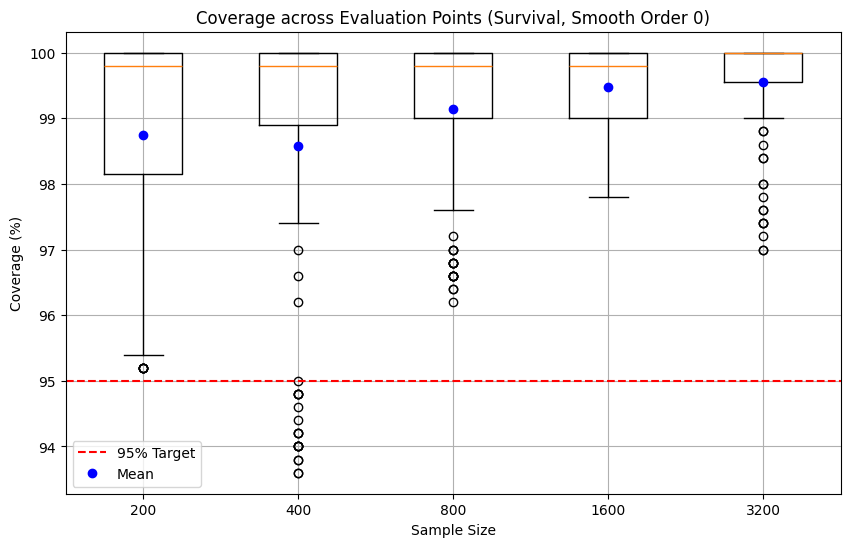

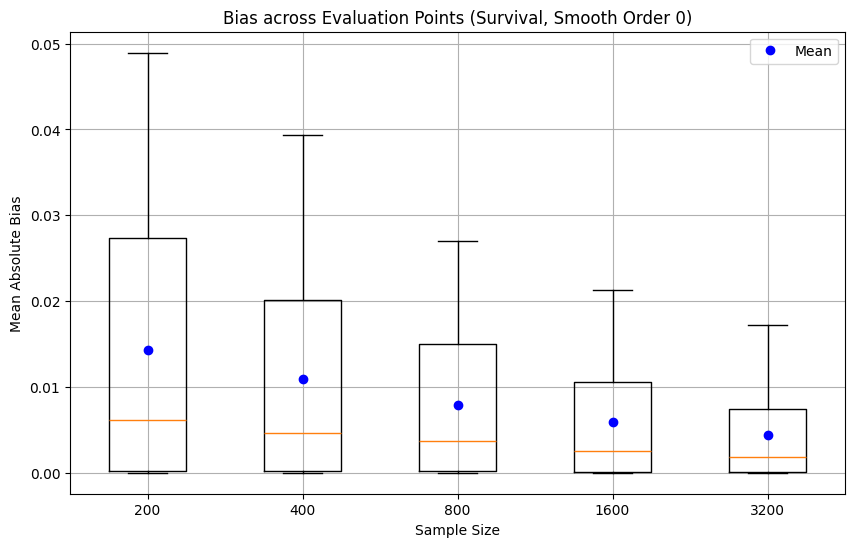

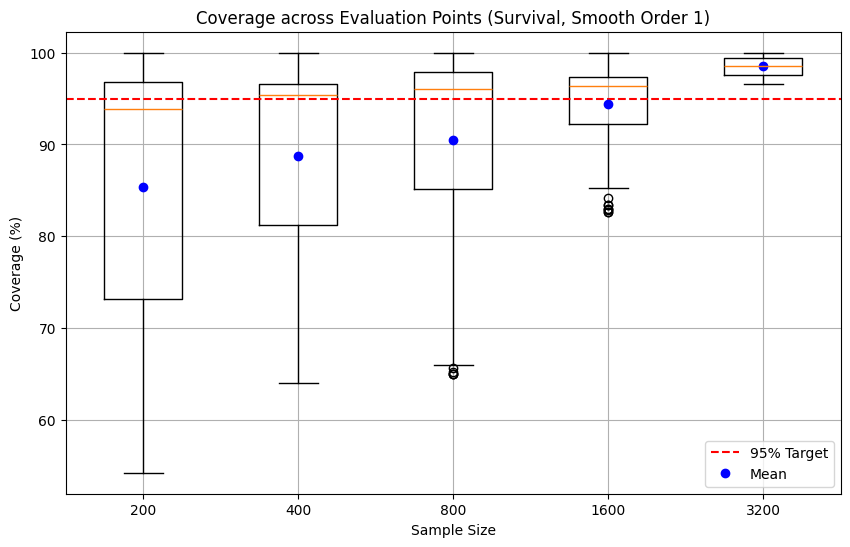

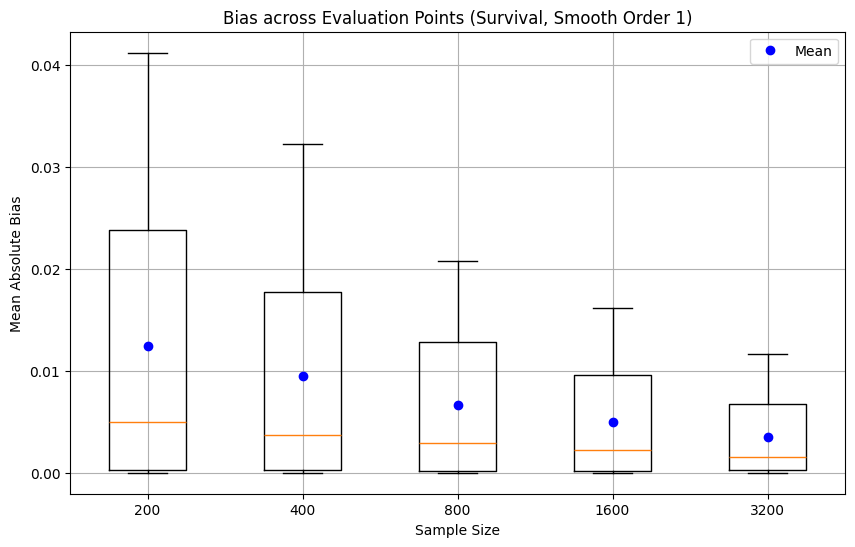

In [22]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# Define a function to compute the true survival (using the survival function)
def compute_true_survival(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.sf(grid_points, a, b, loc=mean, scale=std)


# Get all final survival CSV files (adjust the pattern if needed)
survival_files = glob.glob(os.path.join(folder_path, "*final_survival.csv"))

# Dictionaries to store aggregated coverage and bias data per (sample size, smooth order)
coverage_data_surv = {}
bias_data_surv = {}

# Loop over each survival file
for survival_file in survival_files:
    basename = os.path.basename(survival_file)
    print("Reading file:", basename)
    # Extract sample size and smooth order from the file name.
    # Example filename: "hal_n800_smooth0_final_survival.csv"
    match = re.search(r"hal_n(\d+)_smooth(\d+)_", basename)
    if not match:
        print("No sample size or smooth order found in:", basename)
        continue
    n_samples = int(match.group(1))
    smooth_order = int(match.group(2))
    key = (n_samples, smooth_order)
    
    # Determine the corresponding standard error file name
    se_file = survival_file.replace("final_survival.csv", "final_survival_se.csv")
    if not os.path.exists(se_file):
        print(f"SE file not found for {survival_file}")
        continue

    # Read the CSV files into DataFrames
    survival_df = pd.read_csv(survival_file)
    se_df = pd.read_csv(se_file)
    
    # Assume the first column is the evaluation grid and the rest are simulation experiments
    eval_points = survival_df.iloc[:, 0].values
    true_survival = compute_true_survival(eval_points)
    
    # Lists to store the coverage (%) and bias (mean absolute difference) per evaluation point
    coverage_per_eval = []
    bias_per_eval = []
    
    # Loop over evaluation points (rows)
    for i in range(len(eval_points)):
        # Extract estimated survival values and standard errors for each replicate at evaluation point i
        est_values = survival_df.iloc[i, 1:].astype(float).values
        se_values  = se_df.iloc[i, 1:].astype(float).values
        
        # Construct the 95% confidence intervals (using 1.96*SE)
        lower_bounds = est_values - 1.96 * se_values
        upper_bounds = est_values + 1.96 * se_values
        
        # Coverage: percentage of experiments for which the true survival is inside the CI
        cov_percentage = np.mean((true_survival[i] >= lower_bounds) & (true_survival[i] <= upper_bounds)) * 100
        coverage_per_eval.append(cov_percentage)
        
        # Bias: mean absolute difference between estimated survival and true survival at this grid point
        bias_val = np.mean(np.abs(est_values - true_survival[i]))
        bias_per_eval.append(bias_val)
    
    # Store the results aggregated by (n_samples, smooth_order)
    if key in coverage_data_surv:
        coverage_data_surv[key].extend(coverage_per_eval)
        bias_data_surv[key].extend(bias_per_eval)
    else:
        coverage_data_surv[key] = coverage_per_eval
        bias_data_surv[key] = bias_per_eval

# Group the results by smooth order.
smooth_orders = sorted(set(s for (n, s) in coverage_data_surv.keys()))

for smooth in smooth_orders:
    # For the current smooth order, extract the sample sizes and their corresponding data.
    sample_sizes = sorted(n for (n, s) in coverage_data_surv.keys() if s == smooth)
    coverage_boxplot_data_surv = [coverage_data_surv[(n, smooth)] for n in sample_sizes]
    bias_boxplot_data_surv = [bias_data_surv[(n, smooth)] for n in sample_sizes]
    
    # Plot box plots for Coverage (Survival fits) for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(coverage_boxplot_data_surv)
    plt.axhline(y=95, color='red', linestyle='--', label='95% Target')
    # Compute and overlay the mean for each group.
    means_coverage_surv = [np.mean(group) for group in coverage_boxplot_data_surv]
    plt.plot(range(1, len(means_coverage_surv) + 1), means_coverage_surv,
             marker='o', color='blue', linestyle='None', label='Mean')
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(n) for n in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Coverage (%)")
    plt.title(f"Coverage across Evaluation Points (Survival, Smooth Order {smooth})")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot box plots for Bias (Survival fits) for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(bias_boxplot_data_surv)
    means_bias_surv = [np.mean(group) for group in bias_boxplot_data_surv]
    plt.plot(range(1, len(means_bias_surv) + 1), means_bias_surv,
             marker='o', color='blue', linestyle='None', label='Mean')
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(n) for n in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Mean Absolute Bias")
    plt.title(f"Bias across Evaluation Points (Survival, Smooth Order {smooth})")
    plt.legend()
    plt.grid(True)
    plt.show()


Processing: hal_n1600_smooth1_ridge1e-06_final_survival.csv
Processing: hal_n1600_smooth0_ridge1e-06_final_survival.csv
Processing: hal_n800_smooth1_ridge1e-06_final_survival.csv
Processing: hal_n200_smooth0_ridge1e-06_final_survival.csv
Processing: hal_n3200_smooth1_ridge1e-06_final_survival.csv
Processing: hal_n400_smooth1_ridge1e-06_final_survival.csv
Processing: hal_n800_smooth0_ridge1e-06_final_survival.csv
Processing: hal_n400_smooth0_ridge1e-06_final_survival.csv
Processing: hal_n3200_smooth0_ridge1e-06_final_survival.csv
Processing: hal_n200_smooth1_ridge1e-06_final_survival.csv


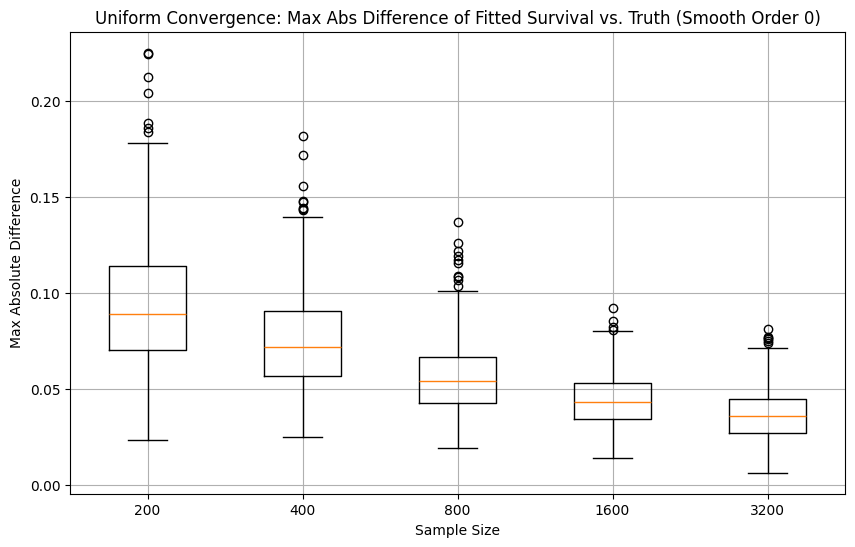

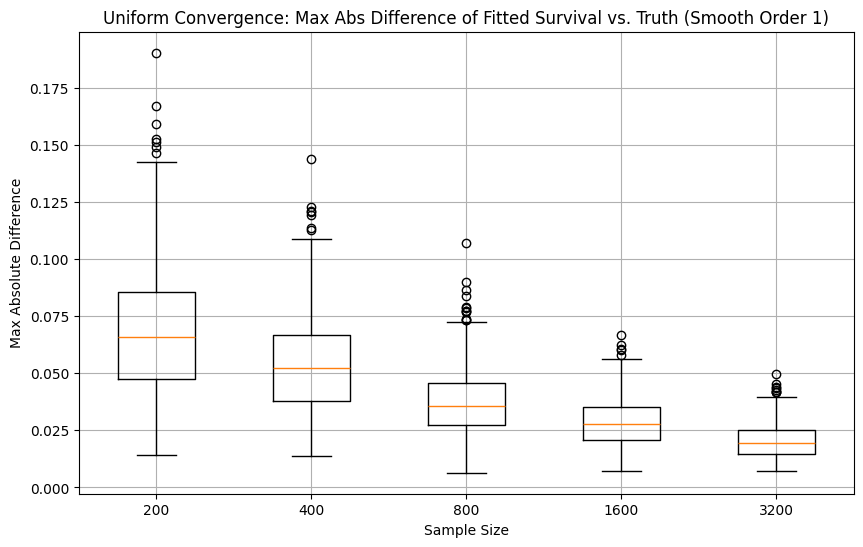

In [21]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# Define a function to compute the true survival (using the survival function)
def compute_true_survival(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.sf(grid_points, a, b, loc=mean, scale=std)



# Get all final survival CSV files (adjust the pattern if needed)
survival_files = glob.glob(os.path.join(folder_path, "*final_survival.csv"))

# Dictionary to store the uniform convergence metric for each (sample size, smooth order).
# For each key, we store a list of maximum absolute differences (one per simulation replicate).
uniform_diff_data_surv = {}

# Loop over each survival file
for survival_file in survival_files:
    basename = os.path.basename(survival_file)
    print("Processing:", basename)
    # Extract both sample size and smooth order from the file name.
    # Example filename: "hal_n800_smooth0_final_survival.csv"
    match = re.search(r"hal_n(\d+)_smooth(\d+)_", basename)
    if not match:
        print("No sample size or smooth order found in:", basename)
        continue
    n_samples = int(match.group(1))
    smooth_order = int(match.group(2))
    key = (n_samples, smooth_order)
    
    # Read the CSV file into a DataFrame
    survival_df = pd.read_csv(survival_file)
    
    # Assume the first column is the evaluation grid and the rest are simulation experiments.
    eval_points = survival_df.iloc[:, 0].values
    true_survival = compute_true_survival(eval_points)
    
    # For each simulation replicate (each column after the first),
    # calculate the maximum absolute difference between the fitted survival and the truth.
    max_diffs = []
    for col in survival_df.columns[1:]:
        # Convert the experiment's estimated survival to float
        est_values = survival_df[col].astype(float).values
        # Compute absolute differences at each evaluation point
        abs_diff = np.abs(est_values - true_survival)
        # The uniform error is the maximum absolute difference over the grid
        max_diff = np.max(abs_diff)
        max_diffs.append(max_diff)
    
    # Aggregate the maximum differences by (sample size, smooth order)
    if key in uniform_diff_data_surv:
        uniform_diff_data_surv[key].extend(max_diffs)
    else:
        uniform_diff_data_surv[key] = max_diffs

# Group the results by smooth order.
smooth_orders = sorted(set(s for (n, s) in uniform_diff_data_surv.keys()))

for smooth in smooth_orders:
    # For the current smooth order, extract sample sizes and corresponding data.
    sample_sizes = sorted(n for (n, s) in uniform_diff_data_surv.keys() if s == smooth)
    uniform_boxplot_data_surv = [uniform_diff_data_surv[(n, smooth)] for n in sample_sizes]
    
    # Plot the box plot for uniform convergence for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(uniform_boxplot_data_surv)
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(n) for n in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Max Absolute Difference")
    plt.title(f"Uniform Convergence: Max Abs Difference of Fitted Survival vs. Truth (Smooth Order {smooth})")
    plt.grid(True)
    plt.show()
